In [1]:
from datetime import datetime
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle
from datetime import datetime
import os
from pathlib import Path
import fsspec

import re
pd.set_option('display.max_columns', None)
sys.path.insert(0, os.path.abspath('../..'))
import repo_paths  # noqa: F401
%load_ext autoreload
%autoreload 2
from loading_runs import load_results_from_pickle, compute_rowwise_metrics, plot_mask_distributions, plot_metric_vs_lambda

In [2]:
def compute_rowwise_metrics(row, just_f1=True, bin_mask_column='binary_mask'):
    g = np.array(row['g_test'])        # shape (n, p)
    pred = np.array(row[bin_mask_column])
    
    # True Positives, False Positives, False Negatives per row
    TP = np.sum((pred == 1) & (g == 1), axis=1)
    FP = np.sum((pred == 1) & (g == 0), axis=1)
    FN = np.sum((pred == 0) & (g == 1), axis=1)
    
    # Compute metrics per row
    TPR = TP / (TP + FN + 1e-10)
    FDR = FP / (TP + FP + 1e-10)
    F1  = 2 * TP / (2 * TP + FP + FN + 1e-10)
    
    # Take mean across all rows in this experiment
    if just_f1 == True:
        return pd.Series({
                'F1' : np.mean(F1)
            })
    else:
        return pd.Series({
                'TPR': np.mean(TPR),
                'FDR': np.mean(FDR),
                'F1' : np.mean(F1)
            })

## Tuning

In [3]:
lmbda_values = list(np.arange(0,1.05,0.05).round(2))

### Hide&Seek

In [4]:
temp = load_results_from_pickle(folder='ICML_experiments/synthetic/tuning/hide_and_seek',
                                        time_threshold='25_09_03_12_00_00',#"25_07_08_14_00_00",
                                        keep_run_type=None,
                                          is_output=False,
                                  numeric_cols = ['lmbda','accuracy', 'roc_auc', 'pct_sig','TPR_mean','FDR_mean','f1','pr_auc']
                                        )

assert (temp.num_syn_features == 11).all()

temp['F1'] = temp.apply(compute_rowwise_metrics, axis=1)

temp = temp.query('syn != "Syn7"')

temp = temp.query('lmbda in @lmbda_values')

In [5]:
temp.groupby(['lmbda'])[['syn','TPR_mean','FDR_mean','f1']].count()

,syn,TPR_mean,FDR_mean,f1
lmbda,,,,
0.00,6,6,6,6
0.05,6,6,6,6
0.10,6,6,6,6
0.15,6,6,6,6
0.20,6,6,6,6
0.25,6,6,6,6
0.30,6,6,6,6
0.35,6,6,6,6
0.40,6,6,6,6


In [6]:
a = temp.groupby(['model','lmbda'])[['TPR_mean','FDR_mean','f1','roc_auc','pr_auc','pct_sig']].mean().sort_values(by='roc_auc',ascending=False).reset_index()
a[['model','lmbda','roc_auc','pr_auc','pct_sig']]

,model,lmbda,roc_auc,pr_auc,pct_sig
0,Hide&Seek,0.15,0.832476,0.843163,0.383418
1,Hide&Seek,0.20,0.832437,0.842938,0.360233
2,Hide&Seek,0.25,0.831897,0.842339,0.355123
3,Hide&Seek,0.30,0.830877,0.841311,0.351526
4,Hide&Seek,0.35,0.829975,0.840409,0.348602
5,Hide&Seek,0.40,0.828918,0.839215,0.345226
6,Hide&Seek,0.10,0.828386,0.839331,0.513483
7,Hide&Seek,0.45,0.827467,0.837771,0.341288
8,Hide&Seek,0.50,0.825717,0.835973,0.335317
9,Hide&Seek,0.55,0.823581,0.833907,0.329441


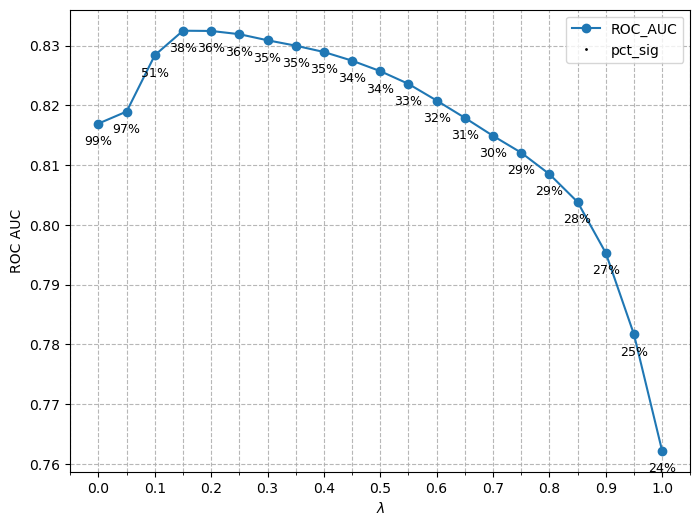

In [7]:
a_sorted = a.sort_values('lmbda')
# Call 1: Sets up the base plot (left y-axis), returns the axis
my_ax = plot_metric_vs_lambda(a_sorted,
                              groupby_cols=None,
                              query='lmbda<2',
                              metric_col='roc_auc',
                              annotate_sig=True,
                             figsize=(8, 6),
                             x_ticks=(0,1.1,0.1))

# Call 2: Uses the existing axis, declares itself a twin (right y-axis)
# plot_metric_vs_lambda(a_sorted,
#                       groupby_cols=None,
#                       query='lmbda<2',
#                       metric_col='f1',
#                       ax=my_ax,
#                       annotate_sig=False,
#                       is_twin=True)

plt.show()

- 0.15 is the best lmbda for roc_auc. But it is close to the 51% sig features. 0.15, 0.2, 0.25 all have 0.832 roc_auc. Should take 0.25 as the one with the most parsimony.
- In fact, 0.25 produces the best results. However, in all the paper's experiments we used the slightly worse 0.3. Will stick with 0.3 for consistency. It is still comparable and quite consistent

In [8]:
a_sorted.sort_values(by='roc_auc', ascending=False)

,model,lmbda,TPR_mean,FDR_mean,f1,roc_auc,pr_auc,pct_sig
0,Hide&Seek,0.15,99.464139,5.876313,96.159786,0.832476,0.843163,0.383418
1,Hide&Seek,0.20,99.213889,2.445081,98.098946,0.832437,0.842938,0.360233
2,Hide&Seek,0.25,98.888972,1.860692,98.277997,0.831897,0.842339,0.355123
3,Hide&Seek,0.30,98.474666,1.557270,98.221867,0.830877,0.841311,0.351526
4,Hide&Seek,0.35,98.066555,1.371061,98.069496,0.829975,0.840409,0.348602
5,Hide&Seek,0.40,97.354361,1.228030,97.690525,0.828918,0.839215,0.345226
6,Hide&Seek,0.10,99.813666,22.027690,85.575804,0.828386,0.839331,0.513483
7,Hide&Seek,0.45,96.380139,1.109716,97.103085,0.827467,0.837771,0.341288
8,Hide&Seek,0.50,94.771694,1.005444,96.089956,0.825717,0.835973,0.335317
9,Hide&Seek,0.55,93.161361,0.889746,95.021976,0.823581,0.833907,0.329441


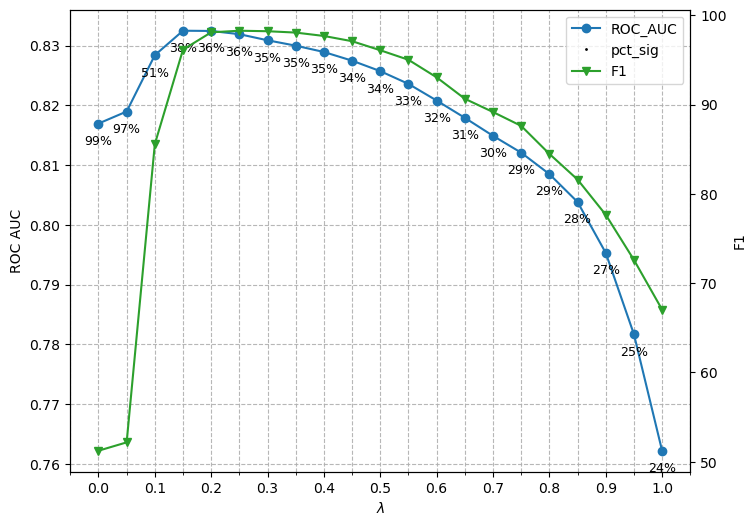

In [10]:
save_path = os.path.join(os.path.abspath('..'), 'figures', 'hs_tuning.pdf') 
save_path = os.path.expanduser(save_path)

a_sorted = a.sort_values('lmbda')
# Call 1: Sets up the base plot (left y-axis), returns the axis
my_ax = plot_metric_vs_lambda(a_sorted,
                              groupby_cols=None,
                              query='lmbda<2',
                              metric_col='roc_auc',
                              annotate_sig=True,
                             figsize=(8, 6),
                             x_ticks=(0,1.1,0.1))

# Call 2: Uses the existing axis, declares itself a twin (right y-axis)
plot_metric_vs_lambda(a_sorted,
                      groupby_cols=None,
                      query='lmbda<2',
                      metric_col='f1',
                      ax=my_ax,
                      annotate_sig=False,
                      is_twin=True)

plt.savefig(save_path, format='pdf', bbox_inches='tight')

plt.show()

In [11]:
temp.query('lmbda==0.3')[['syn','TPR_mean','FDR_mean','f1','roc_auc','pr_auc','pct_sig']]

,syn,TPR_mean,FDR_mean,f1,roc_auc,pr_auc,pct_sig
36,Syn1,97.835000,0.000000,98.196667,0.690114,0.698784,0.177882
37,Syn2,99.995000,0.000000,99.997143,0.893750,0.901741,0.363618
38,Syn3,99.590000,0.000000,99.765714,0.901660,0.907810,0.362145
39,Syn4,98.565333,2.943476,97.574371,0.806779,0.822752,0.373900
40,Syn5,97.228666,2.771738,97.018506,0.809031,0.822313,0.365573
41,Syn6,97.634000,3.628409,96.778803,0.883926,0.894468,0.466036


### INVASE

In [12]:
temp = load_results_from_pickle(folder='ICML_experiments/synthetic/tuning/invase',
                                        time_threshold='25_09_03_12_00_00',#"25_07_08_14_00_00",
                                        keep_run_type=None,
                                          is_output=False,
                                  numeric_cols = ['lmbda','accuracy', 'roc_auc', 'pct_sig','TPR_mean','FDR_mean','f1','pr_auc']
                                        )

assert (temp.num_syn_features == 11).all()

temp['F1'] = temp.apply(compute_rowwise_metrics, axis=1)

temp = temp.query('syn != "Syn7"')
# temp = temp.query('lmbda in @lmbda_values')

In [13]:
temp.groupby(['lmbda'])[['syn','TPR_mean','FDR_mean','f1']].count()

,syn,TPR_mean,FDR_mean,f1
lmbda,,,,
0.00,6,6,6,6
0.01,6,6,6,6
0.05,6,6,6,6
0.10,6,6,6,6
0.15,6,6,6,6
0.20,6,6,6,6
0.25,6,6,6,6
0.30,6,6,6,6
0.35,6,6,6,6


In [14]:
a = temp.groupby(['model','lmbda'])[['TPR_mean','FDR_mean','f1','roc_auc','pr_auc','pct_sig']].mean().sort_values(by='roc_auc',ascending=False).reset_index()
a[['model','lmbda','roc_auc','pr_auc','pct_sig']]

,model,lmbda,roc_auc,pr_auc,pct_sig
0,INVASE,0.95,0.785152,0.795924,0.015521
1,INVASE,0.45,0.784950,0.795053,0.147992
2,INVASE,0.90,0.784529,0.795921,0.019045
3,INVASE,0.75,0.784169,0.794304,0.035262
4,INVASE,0.15,0.784137,0.794833,0.314311
5,INVASE,0.20,0.783364,0.793668,0.288955
6,INVASE,1.00,0.783332,0.794096,0.021639
7,INVASE,0.50,0.783085,0.792752,0.108832
8,INVASE,0.01,0.783023,0.794689,0.650018
9,INVASE,0.85,0.782778,0.793377,0.026245


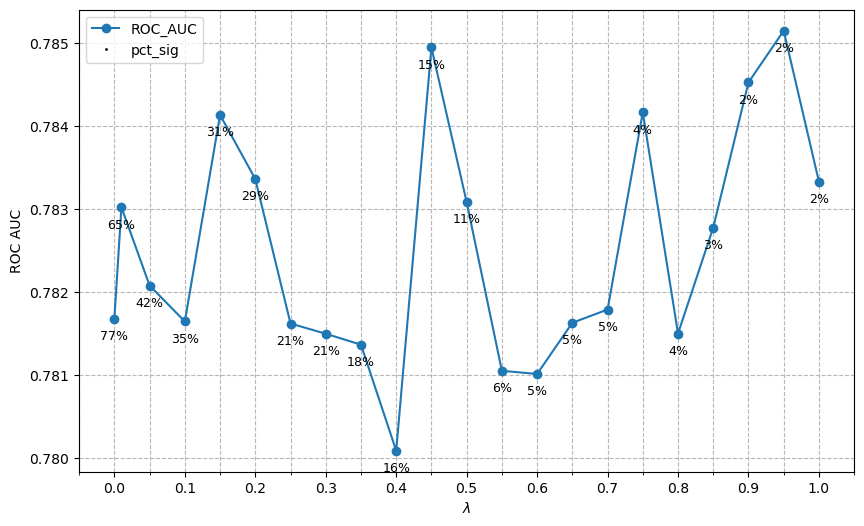

In [16]:
a_sorted = a.sort_values('lmbda')
# Call 1: Sets up the base plot (left y-axis), returns the axis
my_ax = plot_metric_vs_lambda(a_sorted,
                              groupby_cols=None,
                              query='lmbda<2',
                              metric_col='roc_auc',
                              annotate_sig=True,
                             x_ticks=(0,1.1,0.1))

# Call 2: Uses the existing axis, declares itself a twin (right y-axis)
# plot_metric_vs_lambda(a_sorted,
#                       groupby_cols=None,
#                       query='lmbda<2',
#                       metric_col='f1',
#                       ax=my_ax,
#                       annotate_sig=False,
#                       is_twin=True)

plt.show()

- hard to determine. 0.95 is the best lmbda, then 0.45, then 0.15
- we will go with 0.1 because that is what was reported in the INVASE paper as the setting used in this context. They may have had a better tuning technique. But we note the difficulty in choosing it

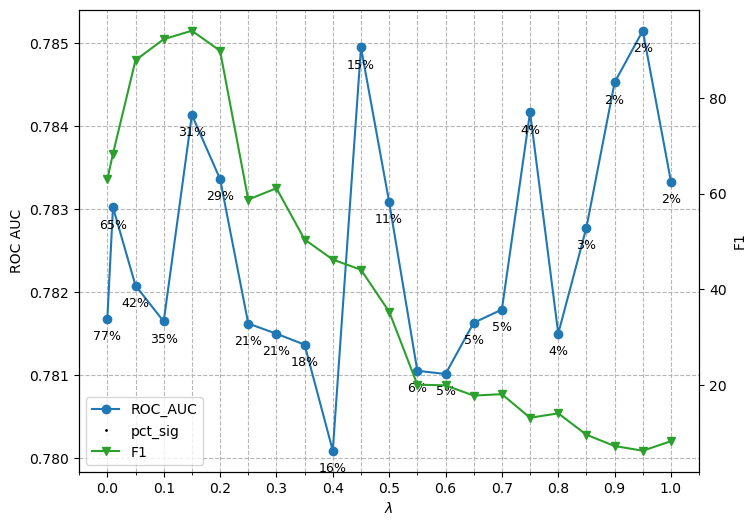

In [17]:
save_path = os.path.join(os.path.abspath('..'), 'figures', 'inv_tuning.pdf') 
save_path = os.path.expanduser(save_path)

a_sorted = a.sort_values('lmbda')
# Call 1: Sets up the base plot (left y-axis), returns the axis
my_ax = plot_metric_vs_lambda(a_sorted,
                              groupby_cols=None,
                              query='lmbda<2',
                              metric_col='roc_auc',
                              annotate_sig=True,
                             figsize=(8, 6),
                             x_ticks=(0,1.1,0.1))

# Call 2: Uses the existing axis, declares itself a twin (right y-axis)
plot_metric_vs_lambda(a_sorted,
                      groupby_cols=None,
                      query='lmbda<2',
                      metric_col='f1',
                      ax=my_ax,
                      annotate_sig=False,
                      is_twin=True,
                     legend_loc='lower left')

plt.savefig(save_path, format='pdf', bbox_inches='tight')


plt.show()

In [18]:
temp.query('lmbda==0.1')[['syn','TPR_mean','FDR_mean','f1','roc_auc','pr_auc','pct_sig']]

,syn,TPR_mean,FDR_mean,f1,roc_auc,pr_auc,pct_sig
12,Syn1,100.000,0.000000,100.000000,0.607696,0.612609,0.181818
13,Syn2,100.000,0.000000,100.000000,0.831998,0.839594,0.363636
14,Syn3,88.270,0.000000,93.297143,0.883122,0.889304,0.320982
15,Syn4,89.736,26.312452,76.213393,0.745893,0.769122,0.480182
16,Syn5,85.368,1.403786,90.383829,0.768206,0.781706,0.332136
17,Syn6,90.182,1.522433,93.640833,0.852959,0.868116,0.420791


### REAL-x

In [19]:
temp = load_results_from_pickle(folder='ICML_experiments/synthetic/tuning/realx',
                                        time_threshold='25_09_03_12_00_00',#"25_07_08_14_00_00",
                                        keep_run_type=None,
                                          is_output=False,
                                  numeric_cols = ['lmbda','accuracy', 'roc_auc', 'pct_sig','TPR_mean','FDR_mean','f1','pr_auc']
                                        )

assert (temp.num_syn_features == 11).all()

temp['F1'] = temp.apply(compute_rowwise_metrics, axis=1)

temp = temp.query('syn != "Syn7"')
temp = temp.query('lmbda in @lmbda_values')

In [20]:
temp.groupby(['lmbda'])[['syn','TPR_mean','FDR_mean','f1']].count()

,syn,TPR_mean,FDR_mean,f1
lmbda,,,,
0.00,6,6,6,6
0.05,6,6,6,6
0.10,6,6,6,6
0.15,6,6,6,6
0.20,6,6,6,6
0.25,6,6,6,6
0.30,6,6,6,6
0.35,6,6,6,6
0.40,6,6,6,6


In [21]:
a = temp.groupby(['model','lmbda'])[['TPR_mean','FDR_mean','f1','roc_auc','pr_auc','pct_sig']].mean().sort_values(by='roc_auc',ascending=False).reset_index()
a[['model','lmbda','roc_auc','pr_auc','pct_sig']]

,model,lmbda,roc_auc,pr_auc,pct_sig
0,REAL-x,0.00,0.789704,0.796857,0.829038
1,REAL-x,0.05,0.783395,0.789188,0.540591
2,REAL-x,0.10,0.764537,0.770134,0.404402
3,REAL-x,0.15,0.763817,0.767712,0.352462
4,REAL-x,0.20,0.753547,0.757521,0.319930
5,REAL-x,0.25,0.742461,0.744565,0.298462
6,REAL-x,0.30,0.732778,0.736991,0.251856
7,REAL-x,0.40,0.726257,0.732319,0.173827
8,REAL-x,0.35,0.717131,0.718012,0.230335
9,REAL-x,0.55,0.701312,0.703769,0.060280


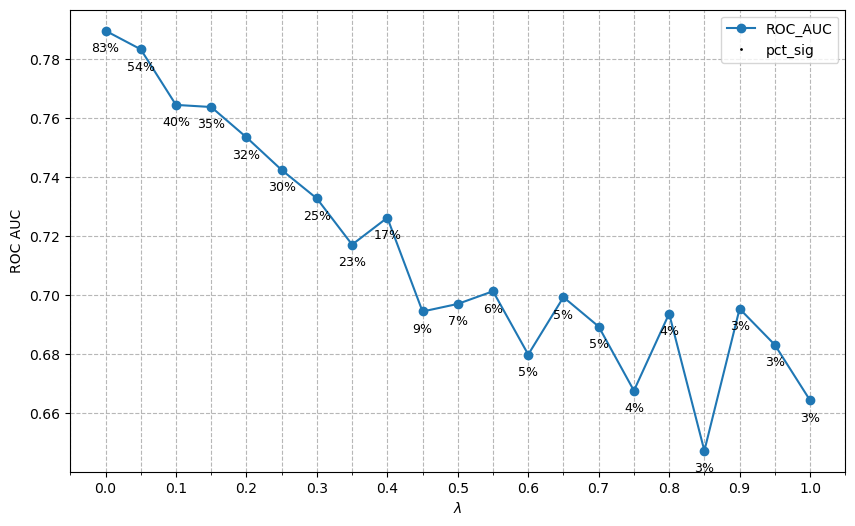

In [22]:
a_sorted = a.sort_values('lmbda')
# Call 1: Sets up the base plot (left y-axis), returns the axis
my_ax = plot_metric_vs_lambda(a_sorted,
                              groupby_cols=None,
                              query='lmbda<2',
                              metric_col='roc_auc',
                              annotate_sig=True,
                             x_ticks=(0,1.1,0.1))

# Call 2: Uses the existing axis, declares itself a twin (right y-axis)
# plot_metric_vs_lambda(a_sorted,
#                       groupby_cols=None,
#                       query='lmbda<2',
#                       metric_col='f1',
#                       ax=my_ax,
#                       annotate_sig=False,
#                       is_twin=True)

plt.show()

- hard to determine. 0.15 looks to be the best lmbda before a drop off and we know it has a similar number of features to Hide&Seek and ground truth

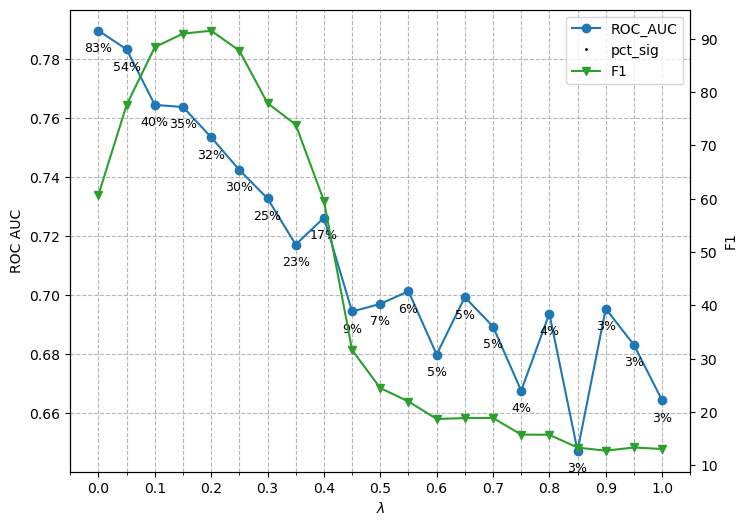

In [23]:
save_path = os.path.join(os.path.abspath('..'), 'figures', 'rlx_tuning.pdf') 
save_path = os.path.expanduser(save_path)

a_sorted = a.sort_values('lmbda')
# Call 1: Sets up the base plot (left y-axis), returns the axis
my_ax = plot_metric_vs_lambda(a_sorted,
                              groupby_cols=None,
                              query='lmbda<2',
                              metric_col='roc_auc',
                              annotate_sig=True,
                             figsize=(8, 6),
                             x_ticks=(0,1.1,0.1))

# Call 2: Uses the existing axis, declares itself a twin (right y-axis)
plot_metric_vs_lambda(a_sorted,
                      groupby_cols=None,
                      query='lmbda<2',
                      metric_col='f1',
                      ax=my_ax,
                      annotate_sig=False,
                      is_twin=True)
plt.savefig(save_path, format='pdf', bbox_inches='tight')

plt.show()

In [24]:
temp.query('lmbda==0.15')[['syn','TPR_mean','FDR_mean','f1','roc_auc','pr_auc','pct_sig']]

,syn,TPR_mean,FDR_mean,f1,roc_auc,pr_auc,pct_sig
18,Syn1,100.000000,19.758333,87.283429,0.631777,0.639781,0.248073
19,Syn2,95.250000,5.437833,94.370135,0.795418,0.781570,0.370600
20,Syn3,87.942500,0.000000,93.110000,0.846928,0.849485,0.319791
21,Syn4,97.902666,11.030571,92.328968,0.717646,0.721581,0.407491
22,Syn5,88.052000,10.500333,87.446973,0.756099,0.764447,0.355236
23,Syn6,87.424000,3.383833,91.336432,0.835037,0.849408,0.413582
